In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/homebrew/Caskroom/miniconda/base/envs/data_analysis/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/data_analysis/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/homebrew/Caskroom/miniconda/base/envs/data_analysis/lib/python3.11/

In [2]:
df = pd.read_csv('../../data/children_products/children_product_cleaned_full_year.csv')
print(f"Размер: {df.shape}")
df.head()

Размер: (4050261, 17)


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,МесяцДаты Заказа,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп
0,2017-01-01 17:15:00,3530280_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ","ГОЛОВНЫЕ УБОРЫ, ВАРЕЖКИ, ПЕРЧАТКИ",ОДЕЖДА,Нет,1,1400.0,1.0,Возврат,Москва,374.87,0,55575454-49504949555170,IDL00023865048,Магазины
1,2017-01-01 17:15:00,3530280_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ","ГОЛОВНЫЕ УБОРЫ, ВАРЕЖКИ, ПЕРЧАТКИ",ОДЕЖДА,Нет,1,1400.0,1.0,Возврат,Москва,374.87,0,55575454-49504949555170,IDL00022519452,Магазины
2,2017-01-01 17:38:00,3530303_TR,Курьерская,ПОДГУЗНИКИ,ПОДГУЗНИКИ,ППКП,Нет,3,1195.0,1.0,Доставлен,Москва,122.25,0,55574851-55555555555176,IDL00038454553,Курьерская
3,2017-01-01 17:38:00,3530318_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ",ВЕРХНЯЯ ДЕТСКАЯ ОДЕЖДА,ОДЕЖДА,Нет,1,2510.0,1.0,Доставлен,Москва,282.94,0,55575054-56575354545171,IDL00035301654,Магазины
4,2017-01-01 17:38:00,3530313_TR,Самовывоз,ИГРУШКИ,КОНСТРУКТОРЫ,ИГРУШКИ,Нет,1,1069.0,1.0,Доставлен,Регионы,83.97,0,55575149-50524951545076,ID9010025983048,Магазины


In [3]:
df.info()
print(df['Статус'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050261 entries, 0 to 4050260
Data columns (total 17 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Дата                 object 
 1   НомерЗаказаНаСайте   object 
 2   МетодДоставки        object 
 3   Группа2              object 
 4   Группа3              object 
 5   Тип                  object 
 6   Отменено             object 
 7   Количество           int64  
 8   Цена                 float64
 9   МесяцДаты Заказа     float64
 10  Статус               object 
 11  Гео                  object 
 12  Маржа                float64
 13  СуммаУслуг           int64  
 14  Телефон_new          object 
 15  ID_SKU               object 
 16  МетодДоставки_Групп  object 
dtypes: float64(3), int64(2), object(12)
memory usage: 525.3+ MB
Статус
Доставлен       2754078
Возврат          796700
Отменен          380943
В процессе        98823
Не определен      19717
Name: count, dtype: int64


In [4]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
print(f"После фильтрации: {df_filtered.shape}")

После фильтрации: (2649178, 17)


In [5]:
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])
print(f"Диапазон дат: {df_filtered['Дата'].min()} - {df_filtered['Дата'].max()}")

Диапазон дат: 2017-01-01 17:38:00 - 2017-12-01 19:48:00


In [6]:
MIN_INTERACTIONS = 3

for iteration in range(5):
    user_counts = df_filtered.groupby('Телефон_new').size()
    item_counts = df_filtered.groupby('ID_SKU').size()
    active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
    active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
    before = len(df_filtered)
    df_filtered = df_filtered[
        df_filtered['Телефон_new'].isin(active_users) &
        df_filtered['ID_SKU'].isin(active_items)
    ]
    if len(df_filtered) == before:
        break

n_users = df_filtered['Телефон_new'].nunique()
n_items = df_filtered['ID_SKU'].nunique()
n_interactions = len(df_filtered)
density = n_interactions / (n_users * n_items) * 100
print(f"После фильтрации (≥{MIN_INTERACTIONS} покупок):")
print(f"  Пользователей: {n_users:,}, Товаров: {n_items:,}")
print(f"  Взаимодействий: {n_interactions:,}")
print(f"  Плотность матрицы: {density:.4f}%")

После фильтрации (≥3 покупок):
  Пользователей: 129,421, Товаров: 71,502
  Взаимодействий: 1,694,548
  Плотность матрицы: 0.0183%


In [7]:
interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')
print(f"Уникальных пар: {len(interactions):,}")

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])

user_id_to_phone = dict(zip(interactions['user_id'], interactions['Телефон_new']))
item_id_to_sku = dict(zip(interactions['item_id'], interactions['ID_SKU']))

Уникальных пар: 1,500,008


In [8]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'], how='inner'
).sort_values('Дата')

split_date = interactions_with_date['Дата'].quantile(0.8)
print(f"Дата разделения: {split_date}")

train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()
print(f"Train: {len(train_data):,}, Test: {len(test_data):,}")

Дата разделения: 2017-09-06 11:48:00
Train: 1,355,580, Test: 338,968


In [9]:
train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
test_interactions = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()

train_users = set(train_interactions['user_id'].unique())
test_users = set(test_interactions['user_id'].unique())
print(f"Train users: {len(train_users):,}, Test users: {len(test_users):,}")
print(f"Cold start users: {len(test_users - train_users):,}")

Train users: 112,816, Test users: 47,144
Cold start users: 16,605


## Подготовка обучающих примеров (positive + hard/easy negatives)

In [10]:
# Hard negatives: отмены и возвраты
df_hard_neg = df[(df['Статус'].isin(['Отменен', 'Возврат'])) | (df['Отменено'] == 'Да')].copy()
df_hard_neg['Дата'] = pd.to_datetime(df_hard_neg['Дата'], errors='coerce')
df_hard_neg = df_hard_neg.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])

known_phones = set(interactions['Телефон_new'])
known_skus = set(interactions['ID_SKU'])
df_hard_neg = df_hard_neg[
    df_hard_neg['Телефон_new'].isin(known_phones) &
    df_hard_neg['ID_SKU'].isin(known_skus)
]

phone_to_uid = dict(zip(interactions['Телефон_new'], interactions['user_id']))
sku_to_iid = dict(zip(interactions['ID_SKU'], interactions['item_id']))
df_hard_neg['user_id'] = df_hard_neg['Телефон_new'].map(phone_to_uid)
df_hard_neg['item_id'] = df_hard_neg['ID_SKU'].map(sku_to_iid)

positive_pairs = set(zip(train_interactions['user_id'], train_interactions['item_id']))
hard_neg_pairs = df_hard_neg[['user_id', 'item_id']].drop_duplicates()
hard_neg_pairs = hard_neg_pairs[
    ~hard_neg_pairs.apply(lambda r: (r['user_id'], r['item_id']) in positive_pairs, axis=1)
]
hard_neg_pairs['label'] = 0

print(f"Hard negatives (отмены + возвраты): {len(hard_neg_pairs):,}")

# Easy negatives: случайный сэмплинг до соотношения 1:4
num_positives = len(train_interactions)
target_negatives = num_positives * 4
num_easy_needed = max(0, target_negatives - len(hard_neg_pairs))

def generate_negative_samples(interactions_df, n_items, num_negatives=4):
    user_items = interactions_df.groupby('user_id')['item_id'].apply(set).to_dict()
    negative_samples = []
    for _, row in interactions_df.iterrows():
        user_id = row['user_id']
        negatives_count = 0
        attempts = 0
        while negatives_count < num_negatives and attempts < num_negatives * 10:
            neg_item = np.random.randint(0, n_items)
            attempts += 1
            if neg_item not in user_items.get(user_id, set()):
                negative_samples.append({'user_id': user_id, 'item_id': neg_item, 'label': 0})
                negatives_count += 1
    return pd.DataFrame(negative_samples)

n_items_total = len(item_encoder.classes_)
easy_per_positive = max(1, int(np.ceil(num_easy_needed / num_positives)))
train_easy_negatives = generate_negative_samples(train_interactions, n_items_total, num_negatives=easy_per_positive)
if len(train_easy_negatives) > num_easy_needed:
    train_easy_negatives = train_easy_negatives.sample(n=num_easy_needed, random_state=42)

train_positives = train_interactions[['user_id', 'item_id']].copy()
train_positives['label'] = 1
train_samples = pd.concat([train_positives, hard_neg_pairs, train_easy_negatives], ignore_index=True)
train_samples = train_samples.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Позитивных: {len(train_positives):,}")
print(f"Hard negatives: {len(hard_neg_pairs):,}")
print(f"Easy negatives: {len(train_easy_negatives):,}")
print(f"Всего: {len(train_samples):,}")

Hard negatives (отмены + возвраты): 335,247
Позитивных: 1,207,042
Hard negatives: 335,247
Easy negatives: 4,492,921
Всего: 6,035,210


In [11]:
class NCFDataset(Dataset):
    def __init__(self, user_ids, item_ids, labels):
        self.user_ids = torch.LongTensor(user_ids)
        self.item_ids = torch.LongTensor(item_ids)
        self.labels = torch.FloatTensor(labels)
    def __len__(self):
        return len(self.user_ids)
    def __getitem__(self, idx):
        return self.user_ids[idx], self.item_ids[idx], self.labels[idx]

train_dataset = NCFDataset(
    train_samples['user_id'].values,
    train_samples['item_id'].values,
    train_samples['label'].values
)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
print(f"Dataset: {len(train_dataset):,}, Батчей: {len(train_loader):,}")

Dataset: 6,035,210, Батчей: 23,576


In [12]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=32, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.user_embedding_gmf = nn.Embedding(num_users, emb_dim)
        self.item_embedding_gmf = nn.Embedding(num_items, emb_dim)
        self.user_embedding_mlp = nn.Embedding(num_users, emb_dim)
        self.item_embedding_mlp = nn.Embedding(num_items, emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
        )

        self.fc_out = nn.Linear(emb_dim + hidden_dim // 2, 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [self.user_embedding_gmf, self.item_embedding_gmf,
                    self.user_embedding_mlp, self.item_embedding_mlp]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.constant_(self.fc_out.bias, 0)

    def forward(self, user_ids, item_ids):
        gmf_out = self.user_embedding_gmf(user_ids) * self.item_embedding_gmf(item_ids)
        mlp_out = self.mlp(torch.cat([
            self.user_embedding_mlp(user_ids),
            self.item_embedding_mlp(item_ids)
        ], dim=-1))
        return torch.sigmoid(self.fc_out(torch.cat([gmf_out, mlp_out], dim=-1)).squeeze(-1))


num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NCF(num_users, num_items, emb_dim=32, hidden_dim=32, dropout=0.3).to(device)
print(f"Device: {device}, Params: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu, Params: 12,866,113


In [13]:
from tqdm.notebook import tqdm

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for user_ids, item_ids, labels in loop:
        user_ids = user_ids.to(device)
        item_ids = item_ids.to(device)
        labels = labels.to(device)

        predictions = model(user_ids, item_ids)
        loss = criterion(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: avg_loss={avg_loss:.4f}")

Epoch 1/5:   0%|          | 0/23576 [00:00<?, ?batch/s]

Epoch 1: avg_loss=0.3717


Epoch 2/5:   0%|          | 0/23576 [00:00<?, ?batch/s]

Epoch 2: avg_loss=0.3493


Epoch 3/5:   0%|          | 0/23576 [00:00<?, ?batch/s]

Epoch 3: avg_loss=0.3438


Epoch 4/5:   0%|          | 0/23576 [00:00<?, ?batch/s]

Epoch 4: avg_loss=0.3406


Epoch 5/5:   0%|          | 0/23576 [00:00<?, ?batch/s]

Epoch 5: avg_loss=0.3387


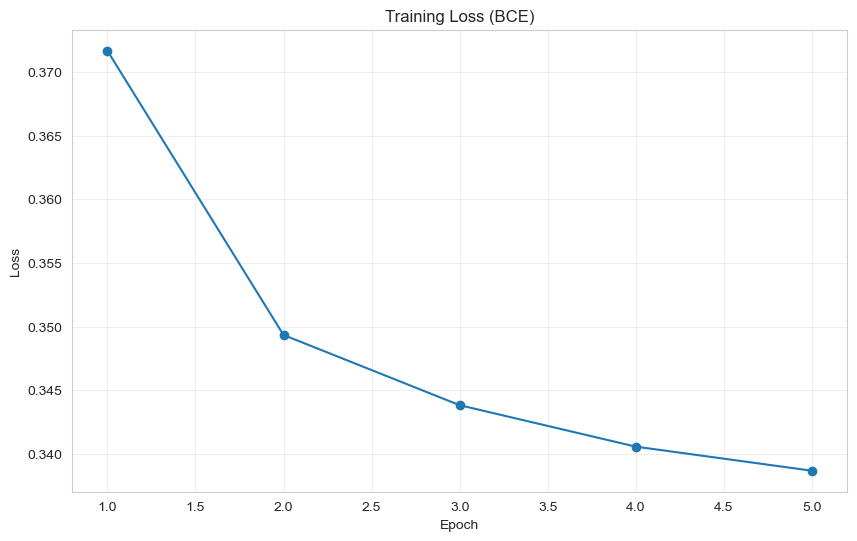

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (BCE)')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
def get_recommendations_ncf(model, user_id, train_interactions, n_items, k=10, device='cpu'):
    model.eval()
    bought_items = set(train_interactions.loc[train_interactions['user_id'] == user_id, 'item_id'].to_numpy())

    items = torch.arange(n_items, device=device, dtype=torch.long)
    users = torch.full_like(items, fill_value=user_id)

    with torch.no_grad():
        scores = model(users, items).detach().cpu()

    candidates_idx = [i for i in range(n_items) if i not in bought_items]
    candidates_scores = [scores[i].item() for i in candidates_idx]

    if not candidates_idx:
        return [], []

    scores_tensor = torch.tensor(candidates_scores)
    topk_scores, topk_pos = torch.topk(scores_tensor, k=min(k, len(candidates_idx)))
    return [candidates_idx[pos] for pos in topk_pos.tolist()], topk_scores.tolist()

In [16]:
def precision_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    rel = set(relevant)
    return len(rec_k & rel) / len(rec_k) if rec_k else 0.0

def recall_at_k(recommended, relevant, k):
    rel = set(relevant)
    return len(set(recommended[:k]) & rel) / len(rel) if rel else 0.0

def map_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in rel:
            hits += 1.0
            score += hits / (i + 1.0)
    return score / min(len(rel), k)

def ndcg_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [17]:
def evaluate_model(model, train_interactions, test_interactions, n_items,
                   k_values=(5, 10, 20), device='cpu'):
    test_user_items = test_interactions.groupby('user_id')['item_id'].apply(list).to_dict()
    train_users = set(train_interactions['user_id'].unique())
    eval_users = [u for u in test_user_items.keys() if u in train_users]

    print(f"Оценка на {len(eval_users):,} пользователях...")

    metrics = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for user_id in eval_users:
        rec_items, _ = get_recommendations_ncf(
            model, user_id, train_interactions, n_items,
            k=max(k_values), device=device
        )
        relevant_items = test_user_items[user_id]
        for k in k_values:
            metrics[k]['precision'].append(precision_at_k(rec_items, relevant_items, k))
            metrics[k]['recall'].append(recall_at_k(rec_items, relevant_items, k))
            metrics[k]['map'].append(map_at_k(rec_items, relevant_items, k))
            metrics[k]['ndcg'].append(ndcg_at_k(rec_items, relevant_items, k))

    return {
        k: {m: float(np.mean(v)) if v else 0.0 for m, v in mv.items()}
        for k, mv in metrics.items()
    }

In [18]:
results = evaluate_model(
    model,
    train_interactions,
    test_interactions,
    n_items=num_items,
    k_values=[5, 10, 20],
    device=device
)

Оценка на 30,539 пользователях...


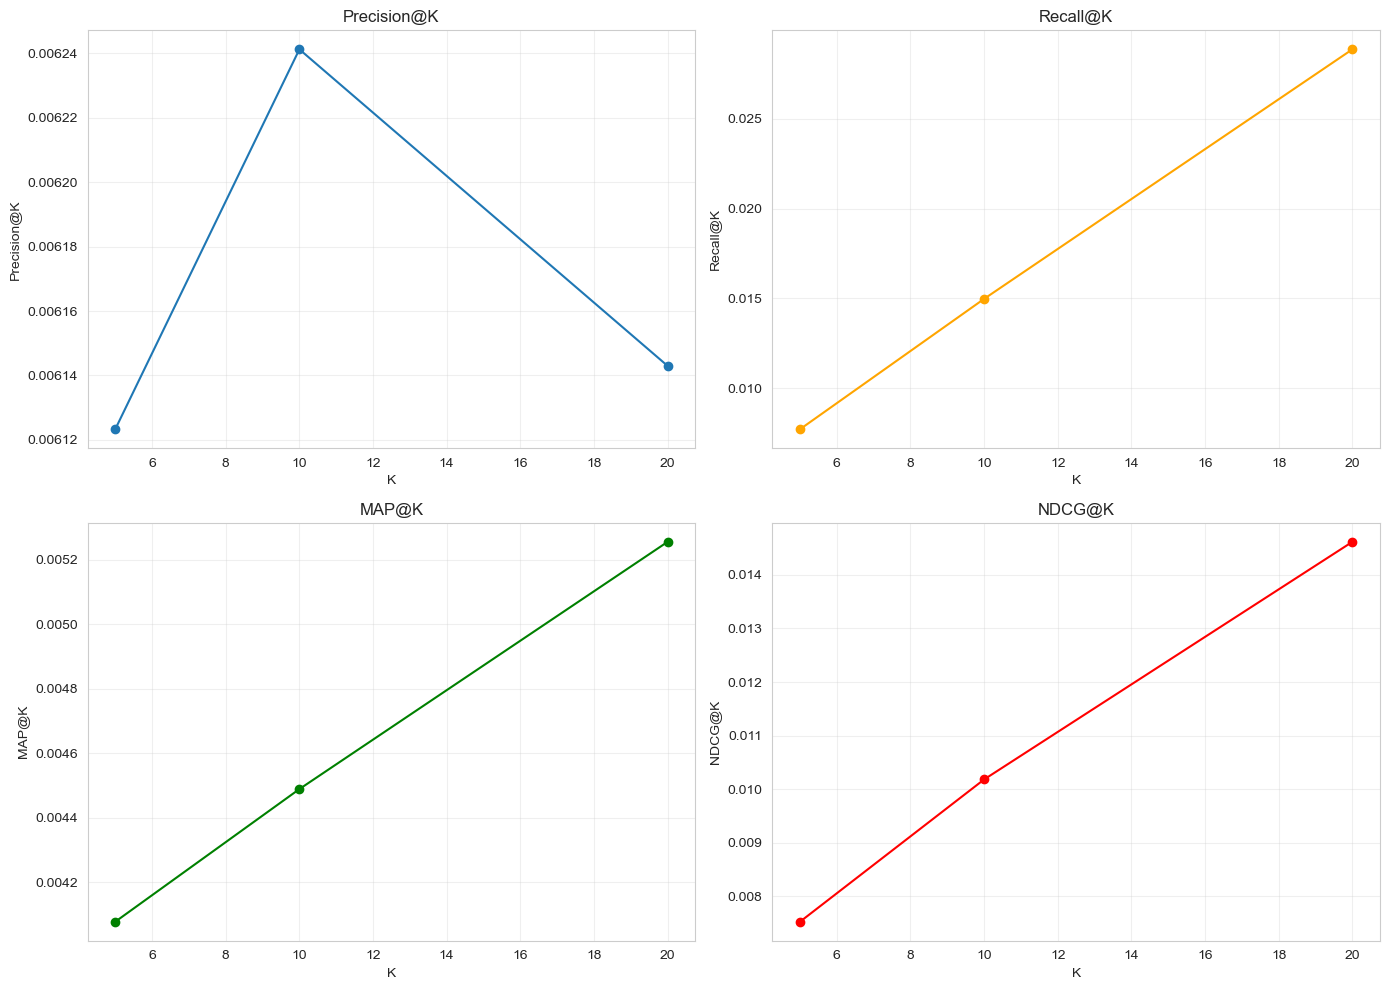

In [19]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', color='orange')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', color='green')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('MAP@K'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', color='red')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('NDCG@K'); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print("=== NCF Metrics (Full Year) ===")
for k in [5, 10, 20]:
    r = results[k]
    print(f"\nK={k}:")
    print(f"  Precision@{k}: {r['precision']:.4f}")
    print(f"  Recall@{k}:    {r['recall']:.4f}")
    print(f"  MAP@{k}:       {r['map']:.4f}")
    print(f"  NDCG@{k}:      {r['ndcg']:.4f}")

=== NCF Metrics (Full Year) ===

K=5:
  Precision@5: 0.0061
  Recall@5:    0.0077
  MAP@5:       0.0041
  NDCG@5:      0.0075

K=10:
  Precision@10: 0.0062
  Recall@10:    0.0150
  MAP@10:       0.0045
  NDCG@10:      0.0102

K=20:
  Precision@20: 0.0061
  Recall@20:    0.0289
  MAP@20:       0.0053
  NDCG@20:      0.0146
